<a href="https://colab.research.google.com/github/rg-smith/remote-sensing-hydro-2026/blob/main/lectures/lecture7-snodas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import rasterio
import os
from datetime import datetime
import requests
import tarfile
import re
import gzip
import shutil
from glob import glob

In [4]:
def get_snodas_data(yyyy,mm,dd,weather_type='us_ssmv11036tS'):
    # us_ssmv11036tS gives modeled snow depth, m/1,000 as of 600 UTC day of
    # us_ssmv11034tS gives modeled SWE, mm, as of 600 UTC day of
    # us_ssmv11044bS gives modeled snow melt, m/100,000 24 hr period ending 600 UTC day of
    # 1. Configuration for data download
    date_str = yyyy+mm+dd
    year = date_str[:4]
    month_str = datetime.strptime(mm, "%m").strftime("%b")
    month = mm+'_'+month_str
    # Base URL for NSIDC SNODAS (adjust if necessary)
    url = f"https://noaadata.apps.nsidc.org/NOAA/G02158/masked/{year}/{month}/SNODAS_{date_str}.tar"

    # check whether file has been downloaded
    download_path = os.path.join('snodas_data', date_str,'*'+weather_type+'*.bil')
    download_complete = glob(download_path)

    if download_complete:
        print('file already downloaded')
        snodas_rast = rasterio.open(download_complete[0])
    else:

        # Create directories
        os.makedirs('snodas_data', exist_ok=True)
        download_path = os.path.join('snodas_data', f"{date_str}.tar")

        # 2. Download the data
        # print(f"Downloading {date_str}...")
        response = requests.get(url)
        with open(download_path, 'wb') as f:
            f.write(response.content)

        # 3. Extract the tar.gz file
        # us_ssmv11036tS__T0001TTNATS2006010105HP001.tar.gz	--	Modeled snow depth
        # print("Extracting files...")

        with tarfile.open(os.path.join('snodas_data',f"{date_str}.tar")) as tar:
            matching_members = [
                member for member in tar.getmembers()
                if re.match(weather_type, member.name)
            ]
            # print(matching_members)
            tar.extractall(path='snodas_data',members=matching_members)

        os.remove(os.path.join('snodas_data',f"{date_str}.tar"))

        def extract_gz(source_filepath, dest_filepath):
            with gzip.open(source_filepath, 'rb') as f_in:
                with open(dest_filepath, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)

        os.makedirs(os.path.join('snodas_data',date_str), exist_ok=True)
        gzfiles = glob(os.path.join('snodas_data','*.gz'))

        hdr_lines = ['byteorder M',
                 'layout bil',
                 'nbands 1',
                 'nbits 16',
                 'ncols 6935',
                 'nrows 3351',
                 'ulxmap -124.729583333333',
                 'ulymap 52.8704166666666',
                 'xdim 0.00833333333333333',
                 'ydim 0.00833333333333333']

        for file in gzfiles:
            extension = os.path.split(file)[1].split('.')[1]
            if extension=='dat':
                extension='bil'
                hdrfname = os.path.join('snodas_data',date_str,os.path.split(file)[1].split('.')[0])+'.hdr'
                with open(hdrfname, 'w') as hdr_file:
                    # Add newline characters to each item in the list
                    hdr_file.writelines(line + '\n' for line in hdr_lines)
            outfile = os.path.join('snodas_data',date_str,os.path.split(file)[1].split('.')[0])+'.'+extension
            extract_gz(file,outfile)
            os.remove(file)

        bilfile = outfile.split('.')[0]+'.bil'
        snodas_rast = rasterio.open(bilfile, 'r+')
    return(snodas_rast)

In [17]:
snodas_swe = get_snodas_data('2026','03','08',weather_type='us_ssmv11034tS')
snodas_swe_2022 = get_snodas_data('2022','03','08',weather_type='us_ssmv11034tS')


/tmp/ipykernel_439/1093072092.py:41: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='snodas_data',members=matching_members)


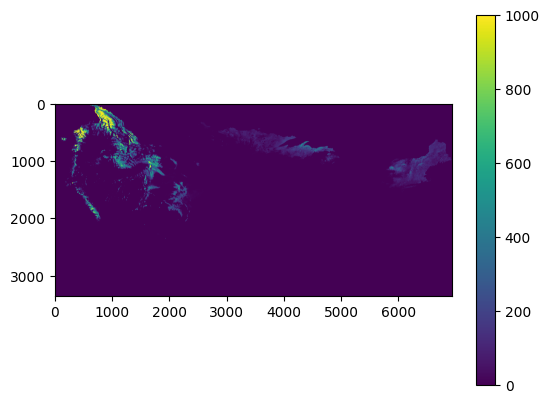

In [18]:
import matplotlib.pyplot as plt
snodas_swe_array = snodas_swe.read(1)
snodas_swe_array[snodas_swe_array>50000] = 0
plt.figure();plt.imshow(snodas_swe_array,vmin=0,vmax=1000);plt.colorbar()

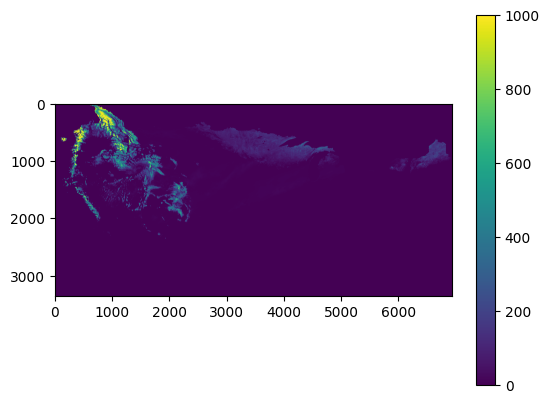

In [19]:
snodas_swe_array_2022 = snodas_swe_2022.read(1)
snodas_swe_array_2022[snodas_swe_array_2022>50000] = 0
plt.figure();plt.imshow(snodas_swe_array_2022,vmin=0,vmax=1000);plt.colorbar()

/tmp/ipykernel_439/2846477398.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.figure();plt.imshow(snodas_swe_array/snodas_swe_array_2022,vmin=0,vmax=2);plt.colorbar()
/tmp/ipykernel_439/2846477398.py:1: RuntimeWarning: invalid value encountered in divide
  plt.figure();plt.imshow(snodas_swe_array/snodas_swe_array_2022,vmin=0,vmax=2);plt.colorbar()


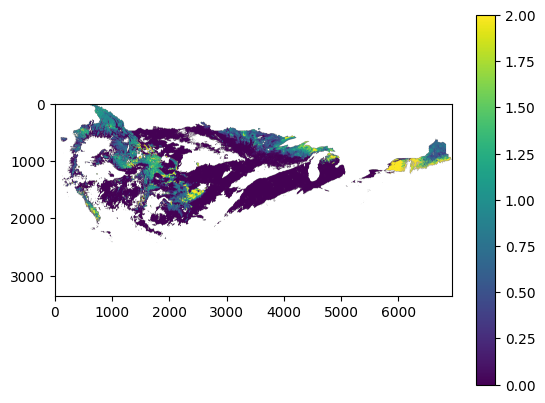

In [23]:
plt.figure();plt.imshow(snodas_swe_array/snodas_swe_array_2022,vmin=0,vmax=2);plt.colorbar()